# Otoczka wypukła - algorytm quickhull

In [20]:
%run interface.ipynb
%run tests.ipynb

### Algorytm Quickhull - algorytm bez wizualizacji

In [3]:
def relative_distance(point, segment):
    # oblicza wzgledna odleglosc punktu od prostej
    a, b = segment.first_point, segment.second_point
    return abs((b.x - a.x) * (a.y - point.y) - (a.x - point.x) * (b.y - a.y))

In [4]:
def position(point, segment):
    # okresla polozenie punktu wzgledem zadanej prostej
    a, b = segment.first_point, segment.second_point
    result = (b.x - a.x) * (point.y - a.y) - (b.y - a.y) * (point.x - a.x)
    return (1 if result > 0 else -1 if result < 0 else 0)

In [5]:
def recursive_algorithm(points, segment):
    
    if not points:
        return []
    
    # znajduje punkt najbardziej oddalony od prostej
    most_distanced_point = max(points, key = lambda point: relative_distance(point, segment))
    points.remove(most_distanced_point)
    
    # tworzy proste i wyznacza zbiory punktow znajdujacych sie nad tymi prostymi
    first_line, second_line = Segment(segment.first_point, most_distanced_point), Segment(most_distanced_point, segment.second_point)
    above_left_line = [point for point in points if position(point, first_line) == 1]
    above_right_line = [point for point in points if position(point, second_line) == 1]
    
    # zwraca punkty nalezace do otoczki wypuklej
    return [most_distanced_point] + recursive_algorithm(above_left_line, Segment(segment.first_point, most_distanced_point)) + recursive_algorithm(above_right_line, Segment(most_distanced_point, segment.second_point))
        

In [6]:
def quickhull(points):
    
    if len(points) <= 2:
        return points
    
    # znajduje punkty skrajne pod wzgledem wspolrzednej x
    left_extreme = min(points, key = lambda point: point.x)
    right_extreme = max(points, key = lambda point: point.x)
    
    segment = Segment(left_extreme, right_extreme)
    
    # dzieli zbior punktow na te znajdujace sie pod prosta oraz nad prosta
    points_below = [point for point in points if position(point, segment) == -1]
    points_above = [point for point in points if position(point, segment) == 1]
    
    # rekurencyjnie wyznacza punkty nalezace do otoczki
    upper_part = recursive_algorithm(points_above, segment)
    lower_part = recursive_algorithm(points_below, segment.reversed())
    
    return [left_extreme, right_extreme] + lower_part + upper_part

### Testy

In [21]:
run_test(quickhull)

Test 1:
	Czas: 0.0s
	Wynik: NIEPOPRAWNY
	Oczekiwano:
	 [Point(1, 1), Point(10, 1), Point(10, 10), Point(1, 10)]
	Otrzymano:
	 [Point(1, 1), Point(10, 1), Point(1, 10), Point(10, 10)]
Test 2:
	Czas: 0.001s
	Wynik: NIEPOPRAWNY
	Oczekiwano:
	 [Point(26.99983489084225, -99.82787980408634), Point(49.4875684177654, -96.98546763401905), Point(86.86938616644139, -89.774442065276), Point(97.03023087264094, -54.2732564291647), Point(97.98243950777251, -7.247447257755567), Point(99.62429973830214, 90.45367284754775), Point(99.51580185367374, 98.5358498628375), Point(-5.837289230972402, 98.83691118752364), Point(-40.29957629237933, 98.47537052300748), Point(-90.38656693287955, 94.99371630110286), Point(-97.04434825584222, 31.491368438355153), Point(-99.10643180807772, -97.51964697896445)]
	Otrzymano:
	 [Point(-99.10643180807772, -97.51964697896445), Point(99.62429973830214, 90.45367284754775), Point(86.86938616644139, -89.774442065276), Point(97.03023087264094, -54.2732564291647), Point(97.9824395

In [22]:
run_time_tests(quickhull)

NameError: name 'run_time_tests' is not defined

### Zadawanie punktów do wyznaczania otoczki

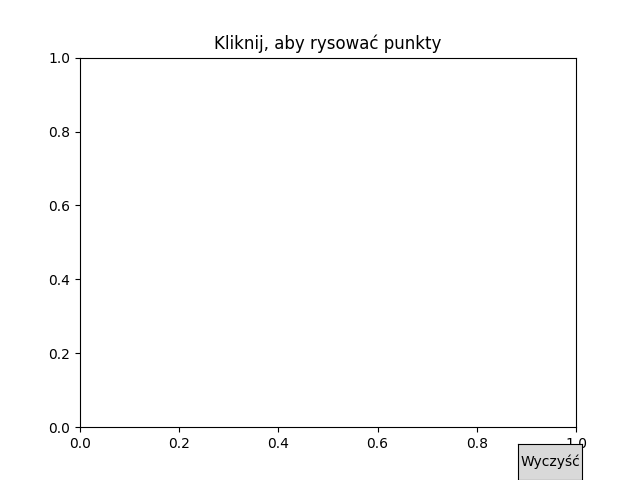

In [47]:
polygon = PolygonDrawer()

### Wizualizacja krokowa algorytmu

In [67]:
def quickhull_visualisation(points):
    visualizer = ConvexHullVisualizer()
    global hull_points
    segments = []
    hull_points = []
    
    if len(points) <= 2:
        return points
    
    left_extreme = min(points, key=lambda point: point.x)
    right_extreme = max(points, key=lambda point: point.x)
    
    segment = Segment(left_extreme, right_extreme)
    segments.append(segment)
    
    points_below = [point for point in points if position(point, segment) == -1]
    points_above = [point for point in points if position(point, segment) == 1]
    
    hull_points = [left_extreme, right_extreme]
    upper_part = recursive_algorithm_visualisation(visualizer, points, points_above, segment, segments)
    lower_part = recursive_algorithm_visualisation(visualizer, points, points_below, segment.reversed(), segments)
    
    display(visualizer.create_animation())


def recursive_algorithm_visualisation(visualizer, all_points, points, segment, segments):
    
    global hull_points
    
    if not points:
        return []
    
    most_distanced_point = max(points, key=lambda point: relative_distance(point, segment))
    points.remove(most_distanced_point)
    
    if most_distanced_point not in hull_points:
        hull_points.append(most_distanced_point)
    
    first_line = Segment(segment.first_point, most_distanced_point)
    second_line = Segment(most_distanced_point, segment.second_point)
    
    visualizer.add_frame(all_points, [hull_points], [], segments, None)
    

    above_left_line = [point for point in points if position(point, first_line) == 1]
    above_right_line = [point for point in points if position(point, second_line) == 1]
    
    return (
        [most_distanced_point] + 
        recursive_algorithm_visualisation(visualizer, all_points, above_left_line, first_line, segments) + 
        recursive_algorithm_visualisation(visualizer, all_points, above_right_line, second_line, segments)
    )

In [70]:
quickhull_visualisation(polygon.points)